/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
<ipython-input-1-dc0cd13f76b9>:64: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(mse - prev_mse) < tol:
<ipython-input-1-dc0cd13f76b9>:23: RuntimeWarning: overflow encountered in square
  mse = np.mean((Y - y_pred) ** 2)
<ipython-input-1-dc0cd13f76b9>:56: RuntimeWarning: overflow encountered in matmul
  grad = (2/M) * X.T @ error
<ipython-input-1-dc0cd13f76b9>:56: RuntimeWarning: invalid value encountered in matmul
  grad = (2/M) * X.T @ error
<ipython-input-1-dc0cd13f76b9>:57: RuntimeWarning: invalid value encountered in subtract
  a -= alpha * grad


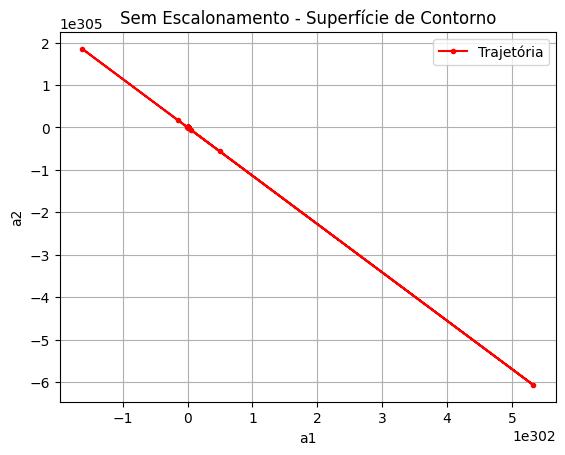

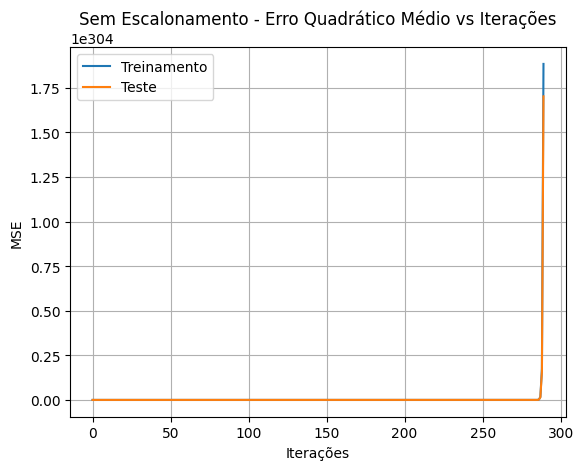

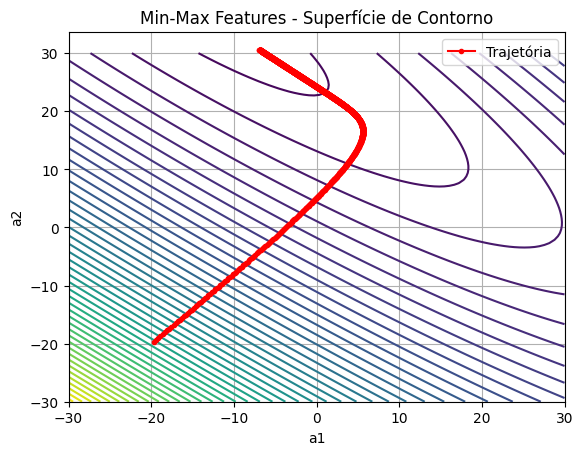

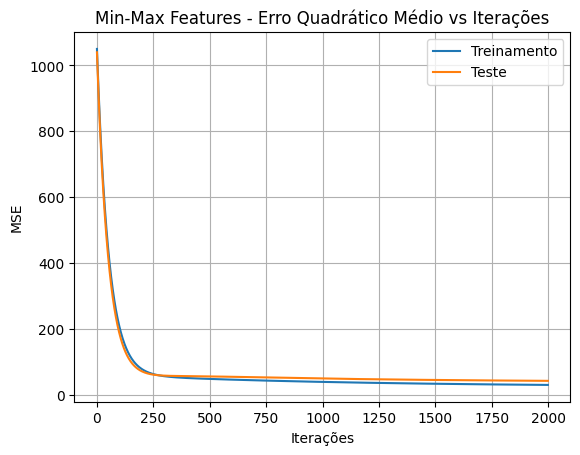

Parou em 280 épocas


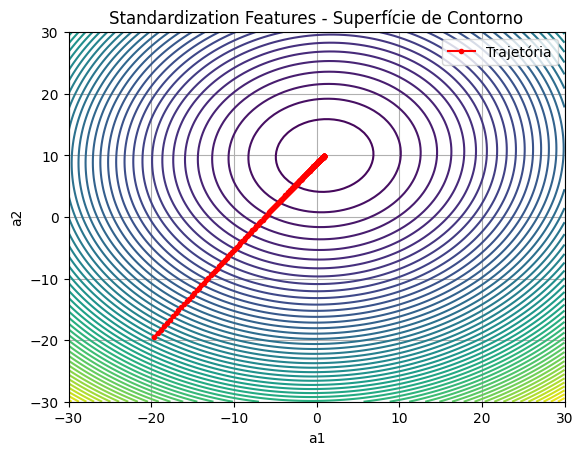

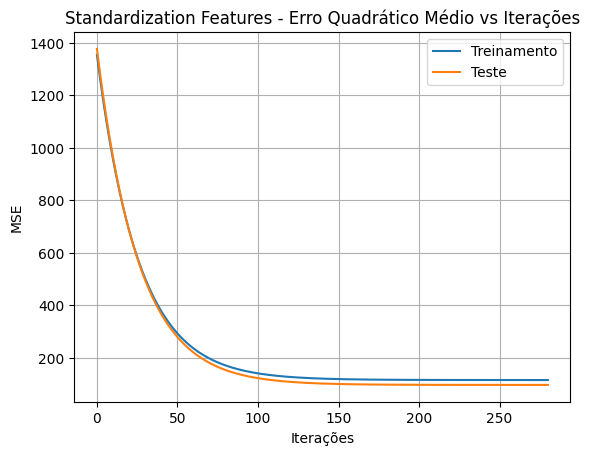

Parou em 470 épocas


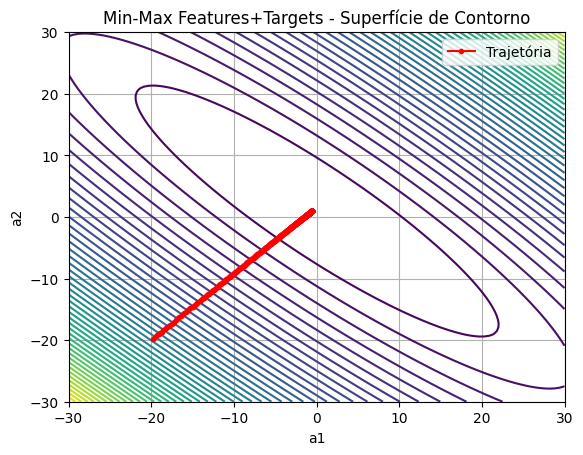

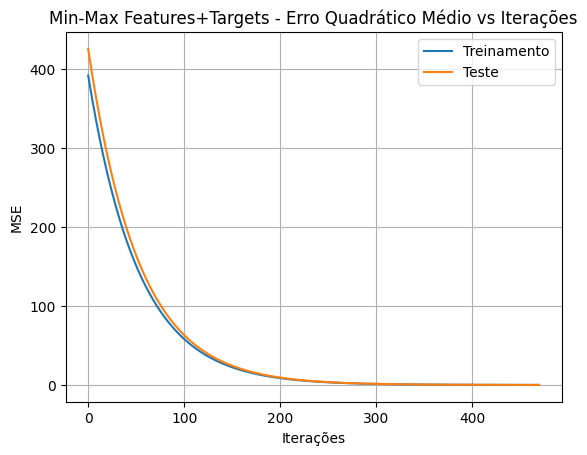

Parou em 268 épocas


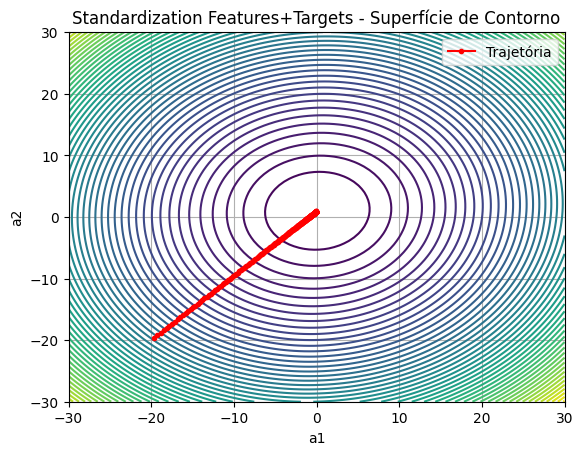

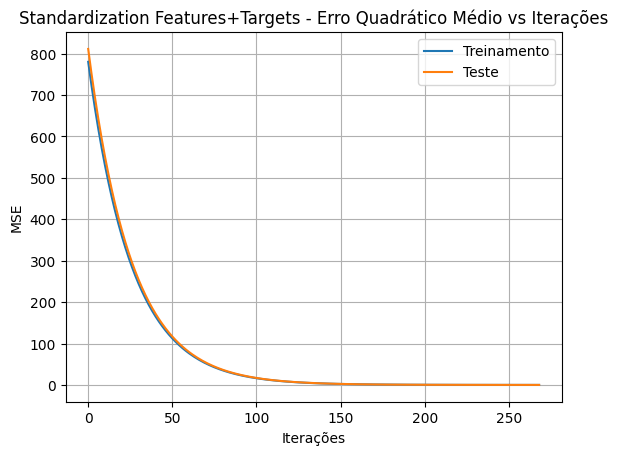

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Configurações iniciais
np.random.seed(42)
M = 1000

# Gerar dados para treino
def gerar_dados(seed):
    np.random.seed(seed)
    x1 = np.random.normal(0, 1, M)
    x2 = np.random.normal(10, 10, M)
    X = np.c_[x1, x2]
    y = x1 + x2
    return X.astype(np.float64), y.reshape(-1, 1).astype(np.float64)

X_train, y_train = gerar_dados(42)
X_test, y_test = gerar_dados(84)

# Funções auxiliares
def compute_mse(X, Y, a):
    y_pred = X @ a
    mse = np.mean((Y - y_pred) ** 2)
    return mse

def plot_surface(X, Y):
    a1_range = np.linspace(-30, 30, 100)
    a2_range = np.linspace(-30, 30, 100)
    A1, A2 = np.meshgrid(a1_range, a2_range)
    MSE_surface = np.zeros_like(A1)

    for i in range(A1.shape[0]):
        for j in range(A1.shape[1]):
            a_tmp = np.array([[A1[i, j]], [A2[i, j]]])
            MSE_surface[i, j] = compute_mse(X, Y, a_tmp)

    return A1, A2, MSE_surface

def min_max_scaler(X):
    return (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

def standard_scaler(X):
    return (X - X.mean(axis=0)) / X.std(axis=0)

def train_gde(X, Y, alpha=0.01, max_epochs=2000, tol=0.001):
    a = np.array([[-20.0], [-20.0]])
    errors = []
    a1_updates = []
    a2_updates = []
    prev_mse = float('inf')
    consec_count = 0

    for epoch in range(max_epochs):
        y_pred = X @ a
        error = y_pred - Y
        grad = (2/M) * X.T @ error
        a -= alpha * grad

        mse = compute_mse(X, Y, a)
        errors.append(mse)
        a1_updates.append(a[0,0])
        a2_updates.append(a[1,0])

        if abs(mse - prev_mse) < tol:
            consec_count += 1
            if consec_count == 2:
                print(f"Parou em {epoch} épocas")
                break
        else:
            consec_count = 0

        prev_mse = mse

    return a, errors, a1_updates, a2_updates

def treino_e_plot(X_train, y_train, X_test, y_test, titulo_prefixo):
    # Treinar modelo
    a_modelo, erros_treino, a1_hist, a2_hist = train_gde(X_train, y_train)

    # Teste
    erros_teste = []
    for a1, a2 in zip(a1_hist, a2_hist):
        a_tmp = np.array([[a1], [a2]])
        mse_test = compute_mse(X_test, y_test, a_tmp)
        erros_teste.append(mse_test)

    # Superfície
    A1, A2, MSE_surface = plot_surface(X_train, y_train)

    # Plots
    plt.figure()
    plt.contour(A1, A2, MSE_surface, levels=50)
    plt.plot(a1_hist, a2_hist, 'r.-', label='Trajetória')
    plt.title(f'{titulo_prefixo} - Superfície de Contorno')
    plt.xlabel('a1')
    plt.ylabel('a2')
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(erros_treino, label='Treinamento')
    plt.plot(erros_teste, label='Teste')
    plt.title(f'{titulo_prefixo} - Erro Quadrático Médio vs Iterações')
    plt.xlabel('Iterações')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid()
    plt.show()

    return a_modelo

# (a) Sem Escalonamento
a_sem = treino_e_plot(X_train, y_train, X_test, y_test, 'Sem Escalonamento')

# (b) Normalização Min-Max (features)
X_train_minmax = min_max_scaler(X_train)
X_test_minmax = min_max_scaler(X_test)
a_minmax = treino_e_plot(X_train_minmax, y_train, X_test_minmax, y_test, 'Min-Max Features')

# (c) Padronização (features)
X_train_std = standard_scaler(X_train)
X_test_std = standard_scaler(X_test)
a_std = treino_e_plot(X_train_std, y_train, X_test_std, y_test, 'Standardization Features')

# (d) Normalização/Padrão também em y
y_train_minmax = min_max_scaler(y_train)
y_test_minmax = min_max_scaler(y_test)
a_minmax_full = treino_e_plot(X_train_minmax, y_train_minmax, X_test_minmax, y_test_minmax, 'Min-Max Features+Targets')

y_train_std = standard_scaler(y_train)
y_test_std = standard_scaler(y_test)
a_std_full = treino_e_plot(X_train_std, y_train_std, X_test_std, y_test_std, 'Standardization Features+Targets')



#e)
Escalonar os atributos (features) é essencial para a estabilidade e eficiência do gradiente descendente.

Escalonar também os targets pode ajudar, mas o ganho é mais sutil e depende do problema.

Padronização (standardization) foi ligeiramente superior à normalização min-max neste caso, pois manteve melhor o formato da superfície de erro.

